# Predicción de Serie Temporal con MLP
## Dataset: Tipo de Cambio MXN/USD — DEXMXUS (FRED)

### ¿Qué hacemos en esta práctica?
Aplicamos un **Perceptrón Multicapa (MLP)** para predecir el valor futuro
del tipo de cambio Peso Mexicano / Dólar USD a partir de los 50 días anteriores.

### ¿Cómo funciona?
- Le damos al modelo una ventana de **50 días** de cotizaciones pasadas
- El modelo aprende el patrón y predice el **día siguiente**
- Entrenamos con el **80%** de los datos históricos (1993–2019 aprox.)
- Evaluamos qué tan bien predice el **20% restante** que nunca vio


### Dataset
- Fuente: **Federal Reserve Economic Data (FRED)**
- Serie: **DEXMXUS** — pesos mexicanos por 1 dólar USD
- Frecuencia: diaria | Período: 1993 – 2025 | ~8000 registros

Dispositivo: cpu
Total registros: 8103
Desde: 1993-11-08  →  Hasta: 2026-03-06


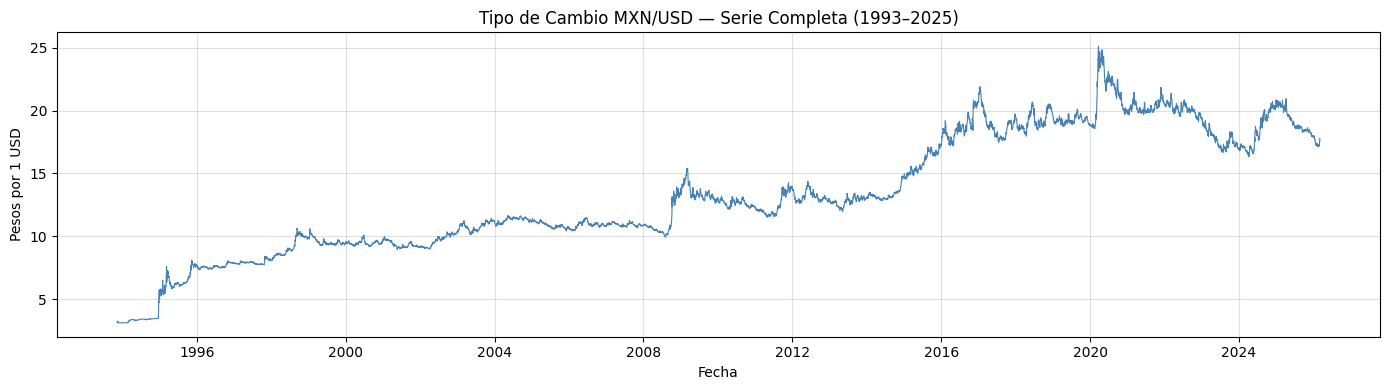

In [ ]:
# Descargamos el dataset completo desde FRED (1993 hasta hoy)
# FRED es el repositorio público del Banco de la Reserva Federal de EE.UU.
import urllib.request
urllib.request.urlretrieve(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXMXUS',
    '/content/DEXMXUS.csv'
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Semillas para reproducibilidad: garantizan los mismos resultados en cada ejecución
np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

# Carga del CSV
# Los días festivos en FRED se representan con '.' → se tratan como NaN y se eliminan
df = pd.read_csv('/content/DEXMXUS.csv', na_values='.')
df.columns = ['DATE', 'DEXMXUS']
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.dropna().sort_values('DATE').reset_index(drop=True)

print(f"Total registros: {len(df)}")
print(f"Desde: {df['DATE'].min().date()}  →  Hasta: {df['DATE'].max().date()}")

# Gráfica exploratoria: visualizamos la serie completa antes de procesarla
plt.figure(figsize=(14, 4))
plt.plot(df['DATE'], df['DEXMXUS'], color='steelblue', linewidth=0.8)
plt.title('Tipo de Cambio MXN/USD — Serie Completa (1993–2025)')
plt.xlabel('Fecha')
plt.ylabel('Pesos por 1 USD')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Normalización [0, 1]
# Las redes neuronales trabajan mejor con valores pequeños y en el mismo rango.
# MinMaxScaler lleva cada valor a [0,1] con la fórmula: (x - min) / (max - min)
# El scaler se ajusta SOLO con el 80% de entrenamiento para evitar data leakage
# (si usáramos todo el dataset, el modelo "vería" el futuro durante el entrenamiento)
values = df['DEXMXUS'].values.astype(np.float32)
n      = len(values)
corte  = int(n * 0.80)

scaler = MinMaxScaler()
scaler.fit(values[:corte].reshape(-1, 1))
scaled = scaler.transform(values.reshape(-1, 1)).flatten().astype(np.float32)

# Ventanas deslizantes: 50 días de entrada → predice el día 51
# Esta es la clave para convertir una serie temporal en un problema supervisado:
#   X[0] = [día1..día50]   →   y[0] = día51
#   X[1] = [día2..día51]   →   y[1] = día52
#   ...así sucesivamente para cada día del dataset
n_steps = 50
X_all, y_all = [], []
for i in range(len(scaled) - n_steps):
    X_all.append(scaled[i : i + n_steps])
    y_all.append(scaled[i + n_steps])

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.float32).reshape(-1, 1)

# División cronológica: NUNCA aleatoria en series temporales
# Si mezcláramos los datos, usaríamos el futuro para predecir el pasado (trampa)
#   80% → entrenamiento (el modelo aprende aquí)
#   10% → validación   (monitoreo durante el entrenamiento, detecta sobreajuste)
#   10% → test final   (evaluación real, el modelo nunca vio estos datos)
N         = len(X_all)
train_end = int(N * 0.80)
val_end   = int(N * 0.90)

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_valid, y_valid = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f"Train : {X_train.shape[0]} muestras (80%)")
print(f"Valid : {X_valid.shape[0]} muestras (10%)")
print(f"Test  : {X_test.shape[0]}  muestras (10%) ← datos nunca vistos por el modelo")

Train : 6442 muestras (80%)
Valid : 805 muestras (10%)
Test  : 806  muestras (10%) ← datos nunca vistos por el modelo


In [ ]:
# TimeSeriesDataset: clase que hereda de torch.utils.data.Dataset
# Permite a PyTorch acceder a las muestras de forma eficiente durante el entrenamiento
# train=True  → devuelve (X, y) — usado en train y validación
# train=False → devuelve solo X  — usado en test para hacer predicciones
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = X
        self.y     = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval':  TimeSeriesDataset(X_valid, y_valid),
    'test':  TimeSeriesDataset(X_test, train=False)
}

# DataLoader: divide los datos en batches de 64 muestras
# shuffle=True en train: mezcla los batches en cada época para mejor aprendizaje
dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

# Modelo MLP: Perceptrón Multicapa
# Arquitectura simple con una sola capa lineal:
#   - Entrada:  50 valores (la ventana de cotizaciones)
#   - Linear(50 → 1): aprende 51 parámetros (50 pesos + 1 bias)
#   - Salida:   1 valor (la predicción del día siguiente)
class MLP(torch.nn.Module):
    def __init__(self, n_in=50, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar: (batch, 50)
        x = self.fc(x)               # capa lineal → (batch, 1)
        return x

mlp = MLP()
print(mlp)
print(f"Parámetros totales: {sum(p.numel() for p in mlp.parameters())}")

MLP(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Parámetros totales: 51


In [ ]:
# fit(): entrena el modelo época por época
# En cada época:
#   1. model.train() → activa el modo entrenamiento (gradientes activos)
#   2. Forward pass  → el modelo predice con los pesos actuales
#   3. MSELoss       → mide el error cuadrático medio entre predicción y real
#   4. loss.backward() → calcula los gradientes (cuánto cambiar cada peso)
#   5. optimizer.step() → Adam actualiza los pesos para reducir el error
#   6. model.eval() + no_grad → evalúa en validación SIN actualizar pesos
def fit(model, dataloader, epochs=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    for epoch in bar:
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())
        bar.set_description(f"loss {np.mean(train_loss):.5f} val_loss {np.mean(eval_loss):.5f}")

# predict(): genera predicciones sobre el conjunto de test
# Usa torch.no_grad() porque en inferencia NO necesitamos calcular gradientes
def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X     = batch
            X     = X.to(device)
            pred  = model(X)
            preds = torch.cat([preds, pred])
        return preds

# plot_series(): función exacta del docente
# Muestra una grilla 3x5 con 15 ejemplos del conjunto de test
# Cada subgráfica muestra:
#   Línea azul   : la ventana de 50 días que el modelo recibió como entrada
#   X azul       : el valor REAL del día siguiente (lo que debería predecir)
#   Círculo rojo : lo que el MLP predijo para ese día
def plot_series(series, y=None, y_pred=None, x_label="Día", y_label="MXN"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix, :], ".-", color='steelblue')
            if y is not None:
                plt.plot(
                    range(len(series[ix, :]), len(series[ix, :]) + len(y[ix])),
                    y[ix], "bx", markersize=10
                )
            if y_pred is not None:
                plt.plot(
                    range(len(series[ix, :]), len(series[ix, :]) + len(y_pred[ix])),
                    y_pred[ix], "ro"
                )
            plt.grid(True)
            plt.hlines(0.5, 0, 60, linewidth=0.5, colors='gray', linestyles='--')
            plt.axis([0, len(series[ix, :]) + 2, 0, 1])
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=12)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=12, rotation=90)
    handles = [
        plt.Line2D([0],[0], color='steelblue', marker='.', label='Ventana 50 días'),
        plt.Line2D([0],[0], color='blue', marker='x', linestyle='None', markersize=10, label='Valor Real'),
        plt.Line2D([0],[0], color='red',  marker='o', linestyle='None', markersize=8,  label='Predicción MLP'),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=12)
    fig.suptitle('MLP — Predicción vs Real (escala normalizada 0–1)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Entrenamos el modelo con 10 épocas
print("Iniciando entrenamiento...\n")
fit(mlp, dataloader, epochs=10)
print("\nEntrenamiento finalizado.")

Iniciando entrenamiento...



loss 0.00023 val_loss 0.00103: 100%|██████████| 10/10 [00:01<00:00,  7.23it/s]


Entrenamiento finalizado.


Período de test: 2022-12-14 → 2026-03-06
Años en el test: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


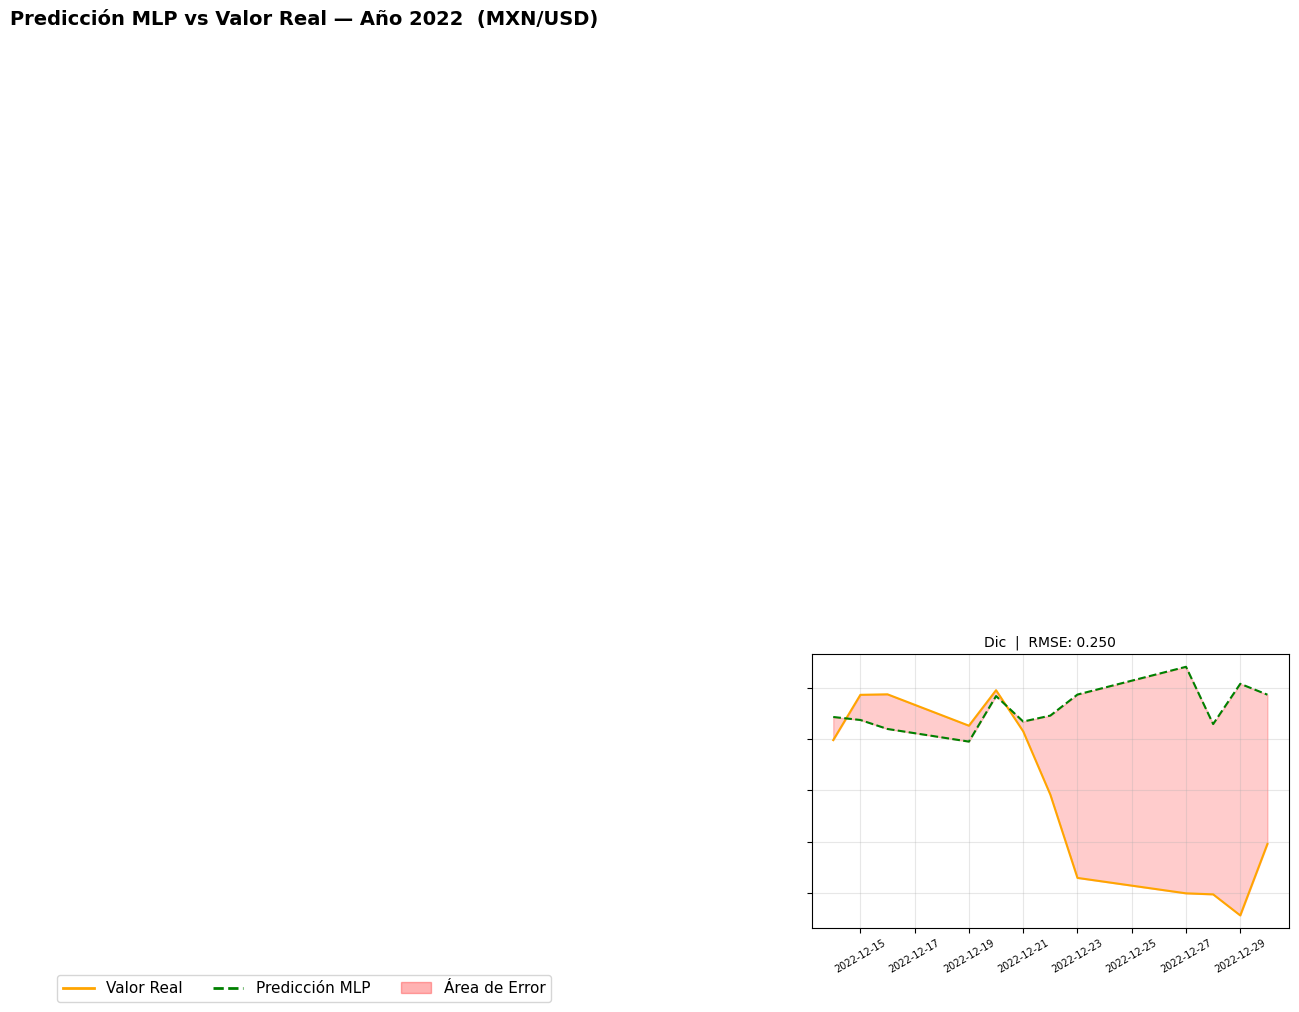

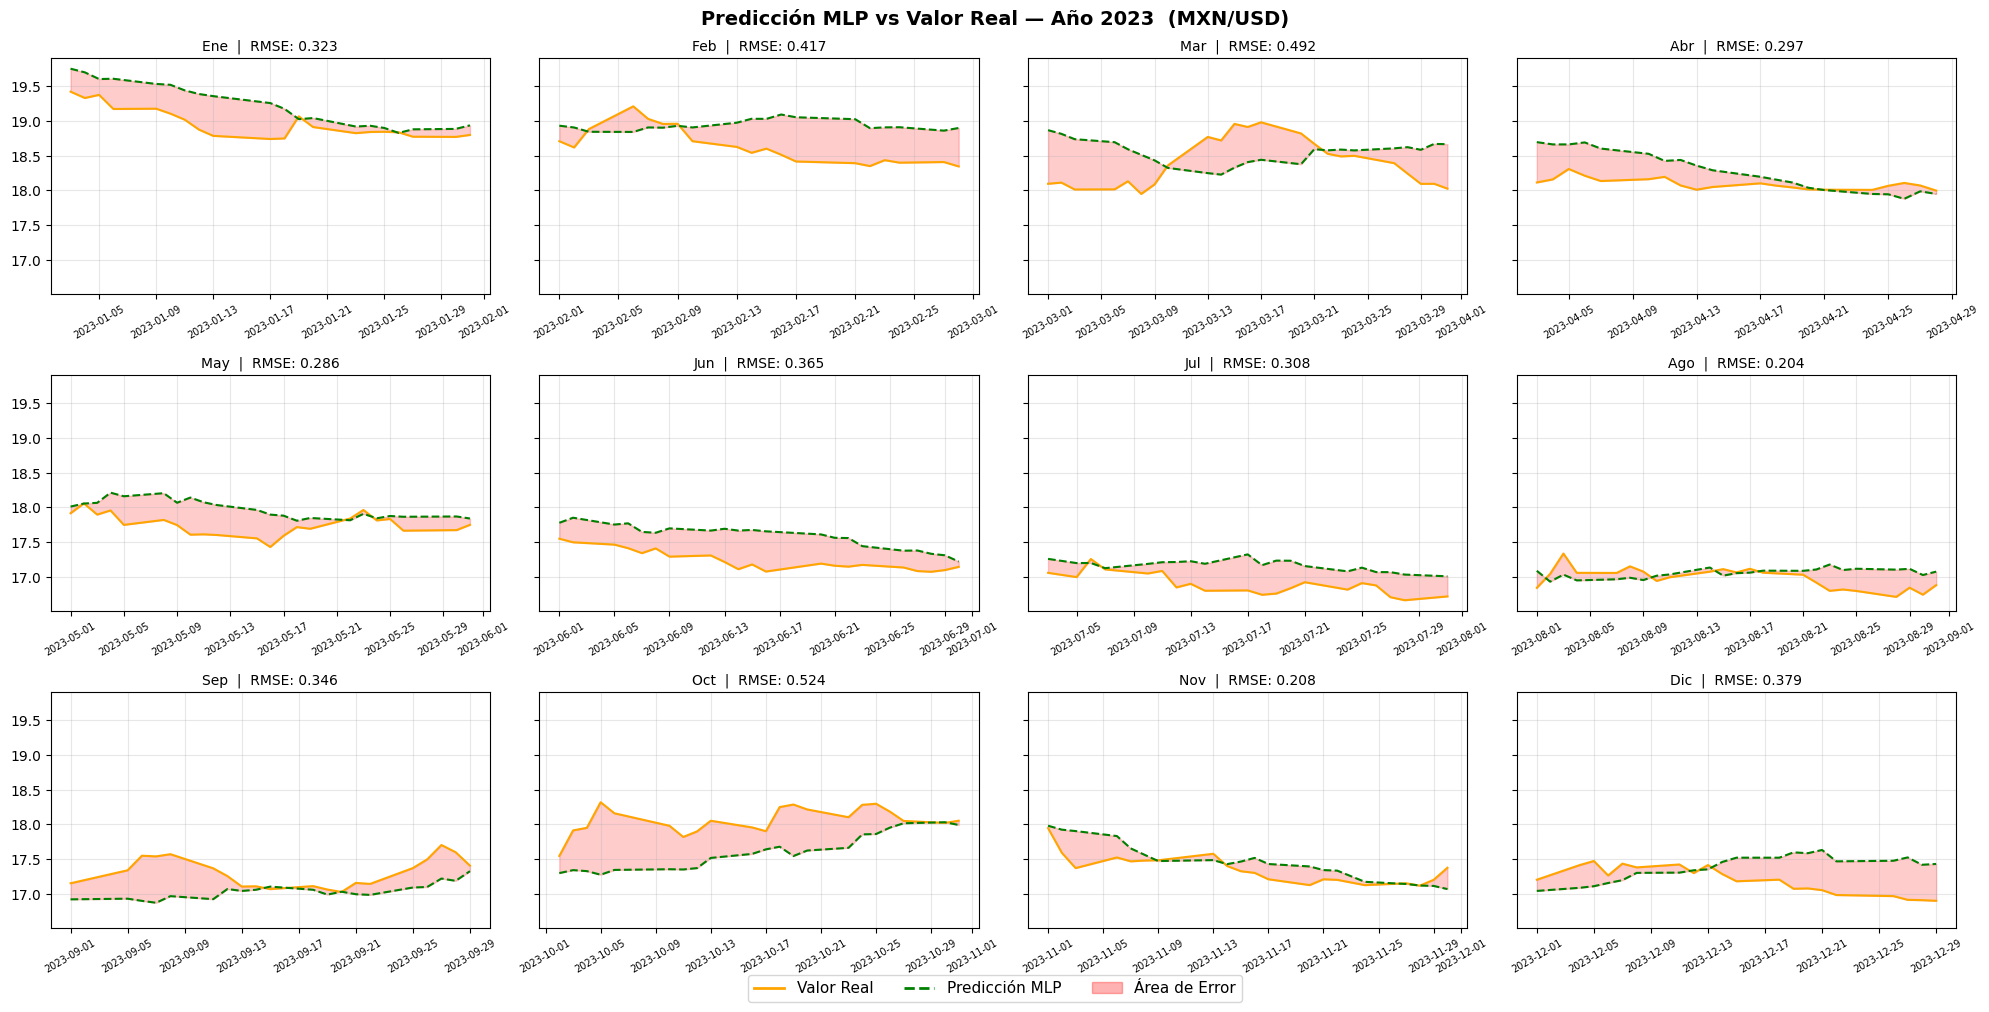

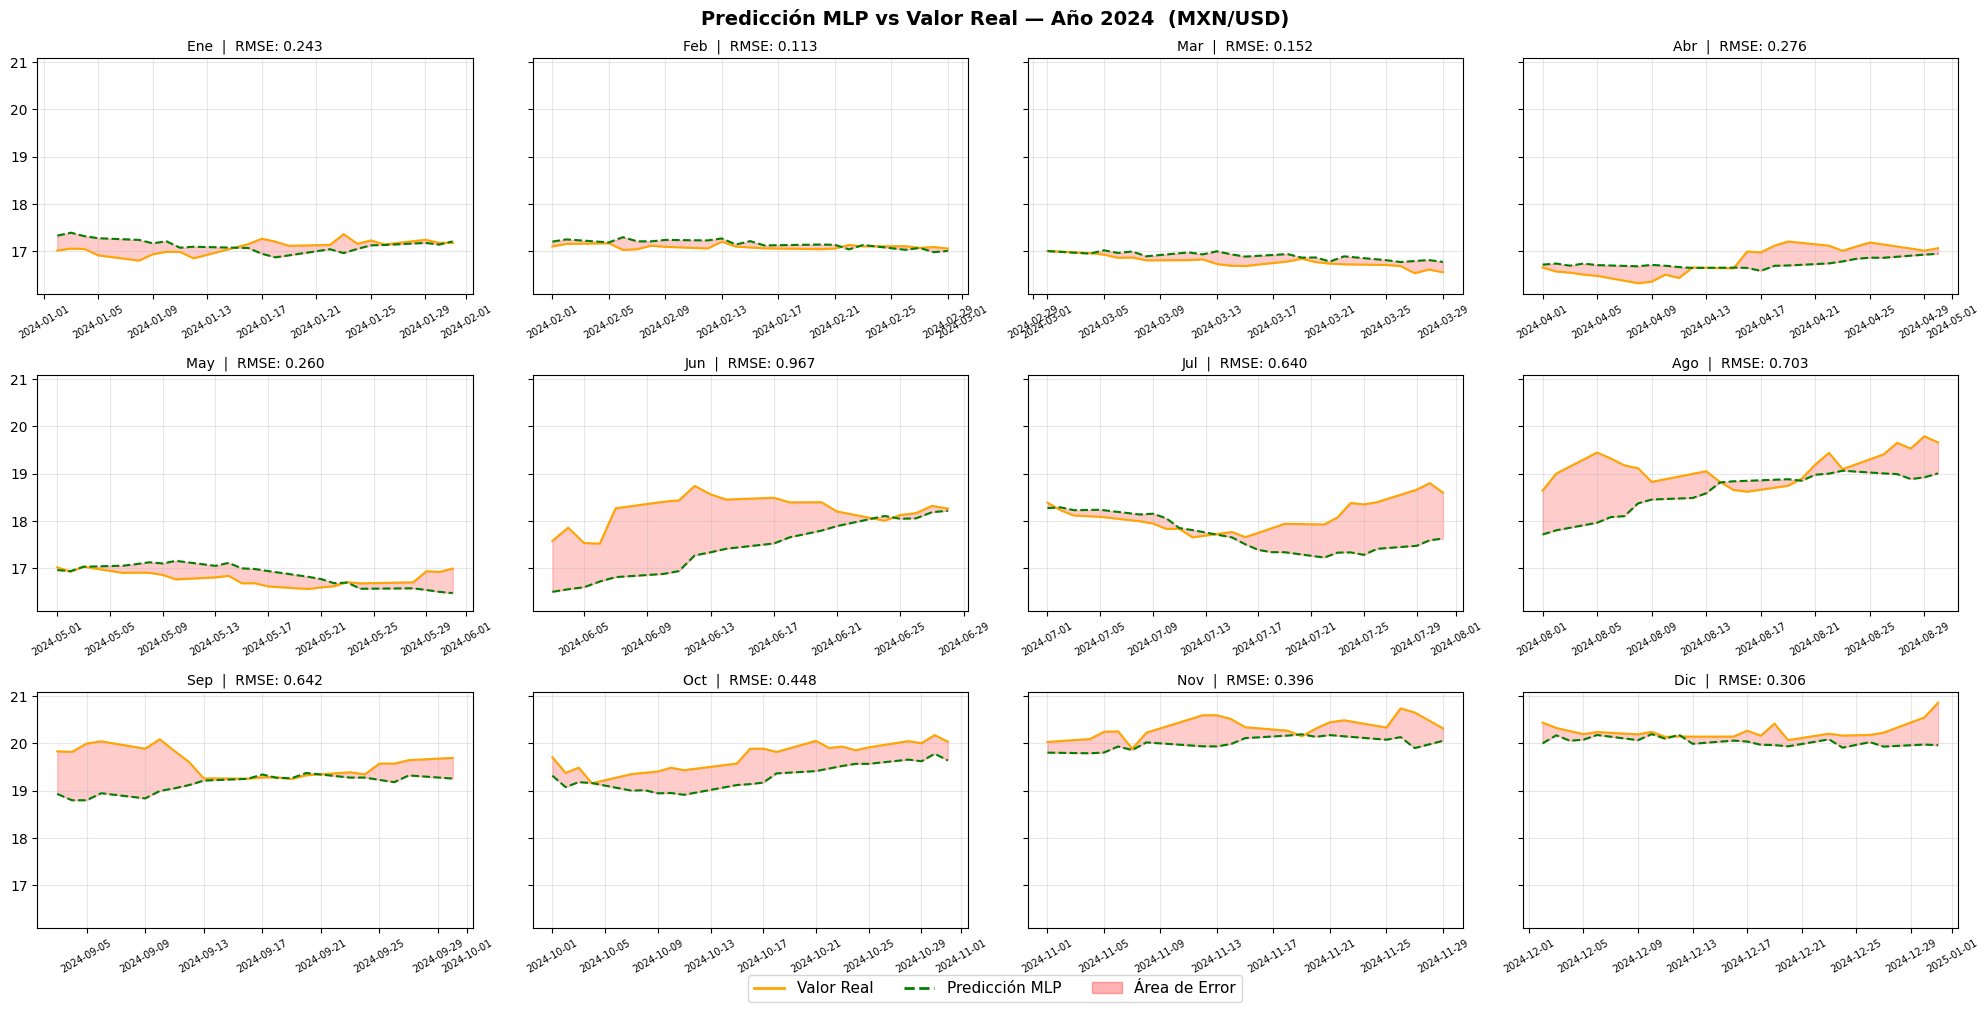

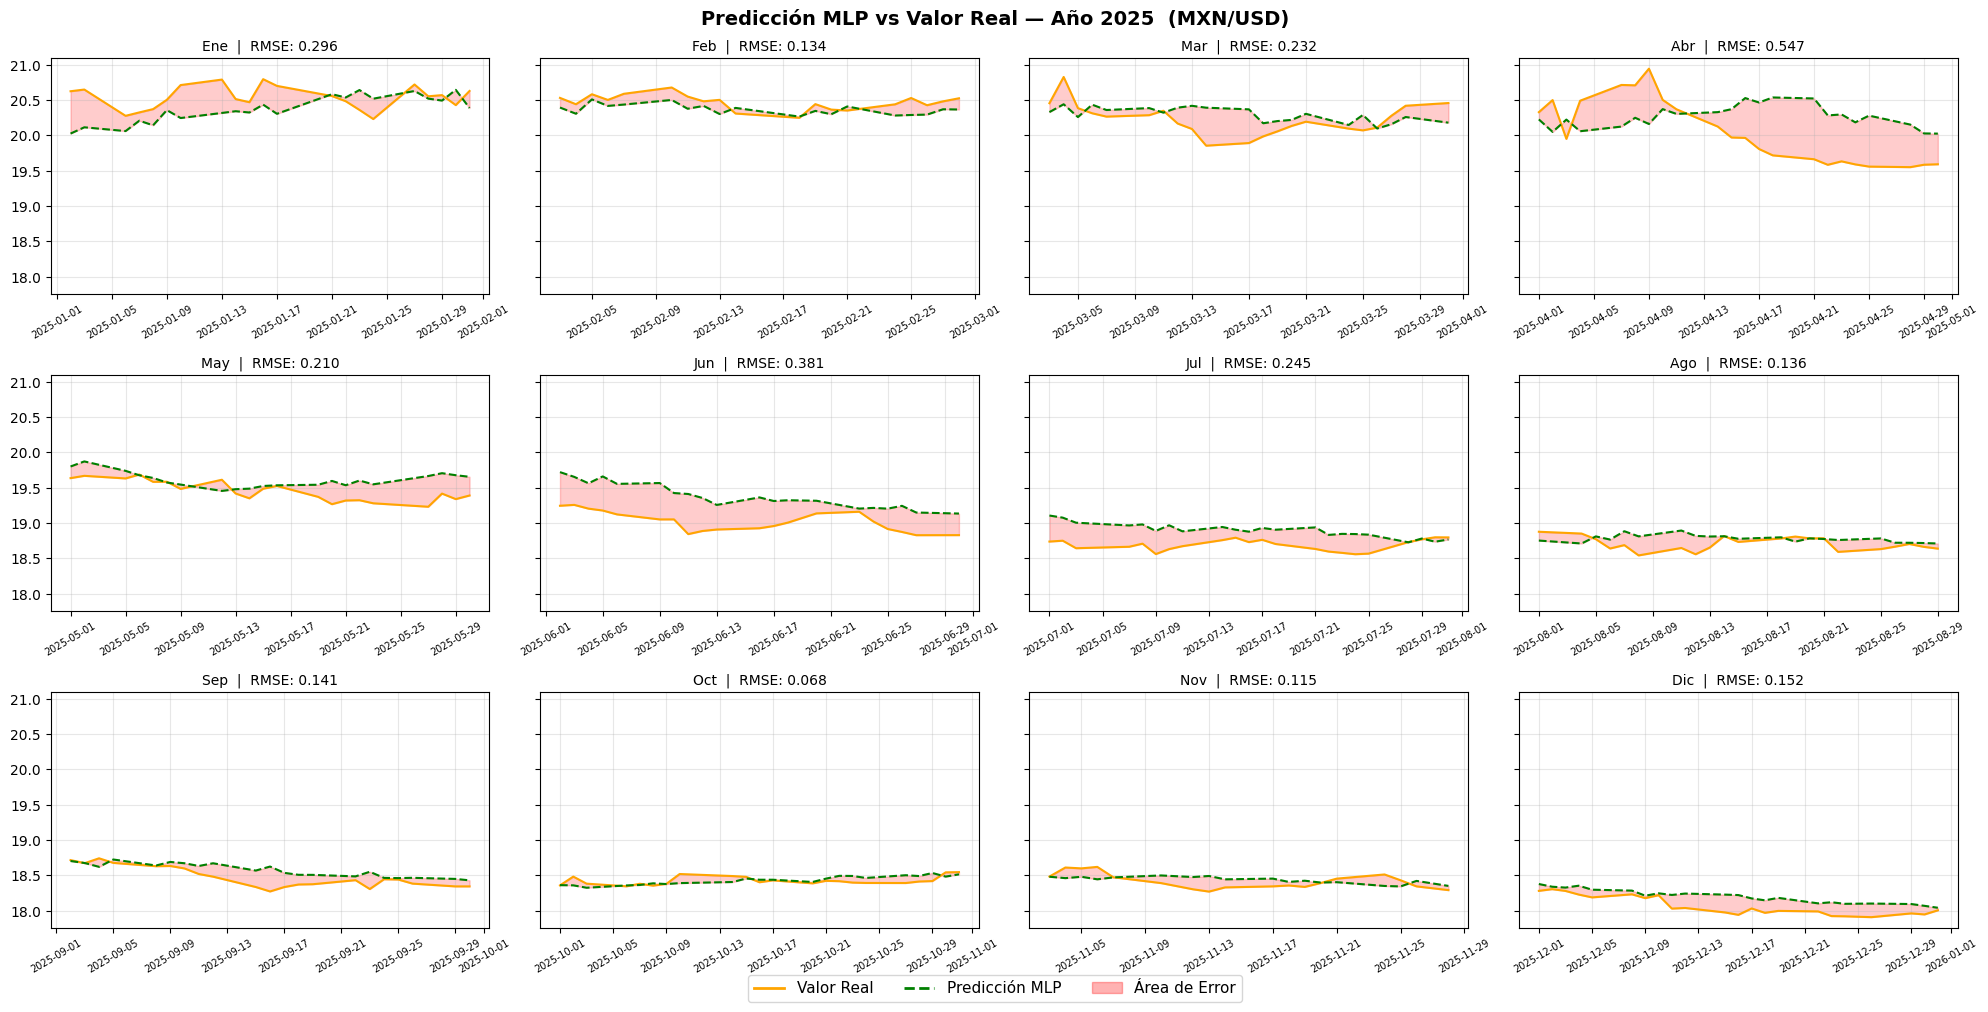

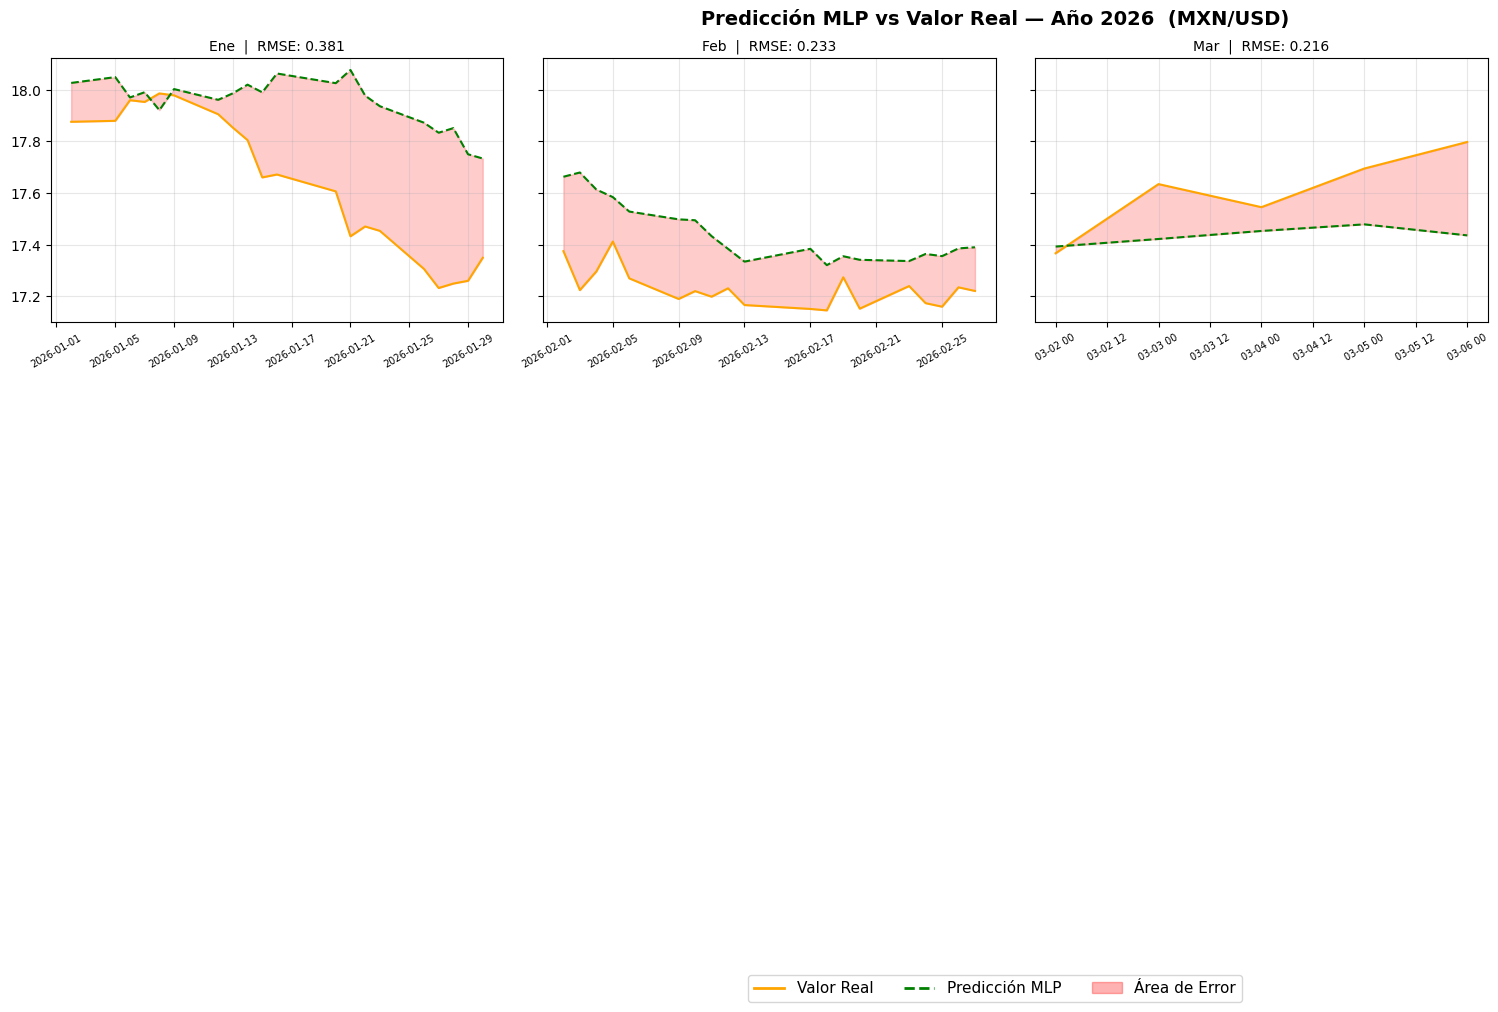

In [ ]:
# Gráficas mes a mes del período de test
# Ahora que y_test_real y y_pred_real ya están calculados (celda 6),
# podemos construir el DataFrame y graficar correctamente.

# Calculamos las fechas exactas del período de test
# val_end es el índice donde termina la validación y empieza el test
fechas_test = df['DATE'].values[n_steps + val_end : n_steps + val_end + len(y_test_real)]
fechas_test = pd.to_datetime(fechas_test)

y_test_real_flat = y_test_real.flatten()
y_pred_real_flat = y_pred_real.flatten()

# Construimos un DataFrame con fechas, valores reales, predicciones y error
df_test = pd.DataFrame({
    'fecha' : fechas_test,
    'real'  : y_test_real_flat,
    'pred'  : y_pred_real_flat,
    'error' : np.abs(y_test_real_flat - y_pred_real_flat)
})
df_test['anio'] = df_test['fecha'].dt.year
df_test['mes']  = df_test['fecha'].dt.month

print(f"Período de test: {fechas_test[0].date()} → {fechas_test[-1].date()}")
print(f"Años en el test: {sorted(df_test['anio'].unique())}")

nombres_meses = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']

# Un panel por cada año del período de test
for anio in sorted(df_test['anio'].unique()):
    df_anio = df_test[df_test['anio'] == anio]

    fig, axes = plt.subplots(3, 4, figsize=(20, 10), sharey=True)
    fig.suptitle(f'Predicción MLP vs Valor Real — Año {anio}  (MXN/USD)',
                 fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for ax_idx in range(12):
        ax  = axes[ax_idx]
        mes = ax_idx + 1
        df_mes = df_anio[df_anio['mes'] == mes]

        # Si ese mes no tiene datos en el test, ocultamos el subplot
        if df_mes.empty:
            ax.set_visible(False)
            continue

        ax.plot(df_mes['fecha'], df_mes['real'],
                color='orange', linewidth=1.5, label='Valor Real')
        ax.plot(df_mes['fecha'], df_mes['pred'],
                color='green',  linewidth=1.5, linestyle='--', label='Predicción MLP')
        ax.fill_between(df_mes['fecha'],
                        df_mes['real'], df_mes['pred'],
                        alpha=0.2, color='red')

        rmse_mes = np.sqrt(mean_squared_error(df_mes['real'], df_mes['pred']))
        ax.set_title(f'{nombres_meses[ax_idx]}  |  RMSE: {rmse_mes:.3f}', fontsize=10)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.grid(True, alpha=0.3)

    # Leyenda corregida: usamos mpatches para el área de error (evita el bug de plt.fill)
    handles = [
        plt.Line2D([0],[0], color='orange', linewidth=2,                  label='Valor Real'),
        plt.Line2D([0],[0], color='green',  linewidth=2, linestyle='--',  label='Predicción MLP'),
        mpatches.Patch(color='red', alpha=0.3,                            label='Área de Error'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               fontsize=11, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()

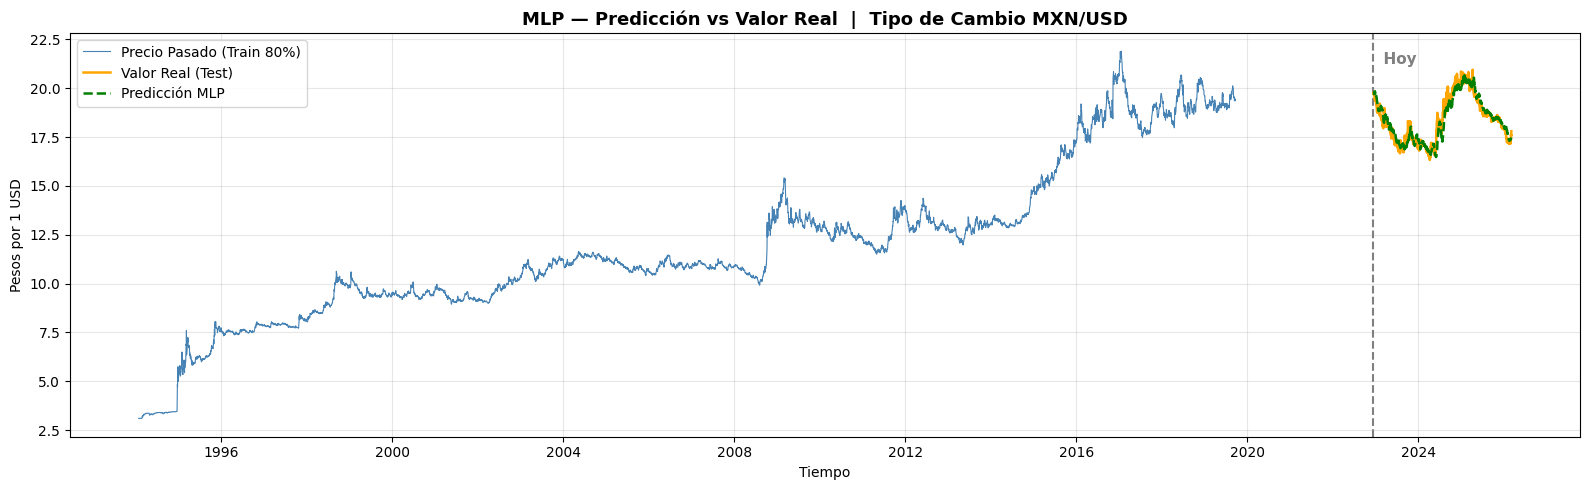


Resumen final del modelo:
  Período evaluado : 2022-12-14 → 2026-03-06
  RMSE : 0.3762 pesos de error promedio por dólar
  MAE  : 0.2772 pesos de error promedio por dólar

Nota: el modelo predice el último tramo del histórico,


In [ ]:
# Gráfica final: pasado (train) → predicción futura (test)
# Idéntica a la imagen del compañero:
#   Azul    : precio histórico usado para entrenar (80%)
#   Naranja : valor real del período de test (lo que ocurrió realmente)
#   Verde   : lo que el MLP predijo para ese mismo período
# La línea "Hoy" marca el punto donde termina el entrenamiento y
# el modelo empieza a predecir sin haber visto los datos.

y_train_real = scaler.inverse_transform(y_train)
fechas_train = pd.to_datetime(df['DATE'].values[n_steps : n_steps + train_end])

plt.figure(figsize=(16, 5))

plt.plot(fechas_train, y_train_real.flatten(),
         color='steelblue', linewidth=0.8, label='Precio Pasado (Train 80%)')

plt.axvline(fechas_test[0], color='gray', linestyle='--', linewidth=1.5)
plt.text(fechas_test[0], y_train_real.max() * 0.97, '  Hoy',
         color='gray', fontsize=11, fontweight='bold')

plt.plot(fechas_test, y_test_real_flat,
         color='orange', linewidth=1.8, label='Valor Real (Test)')

plt.plot(fechas_test, y_pred_real_flat,
         color='green', linewidth=1.8, linestyle='--', label='Predicción MLP')

plt.title('MLP — Predicción vs Valor Real  |  Tipo de Cambio MXN/USD',
          fontsize=13, fontweight='bold')
plt.xlabel('Tiempo')
plt.ylabel('Pesos por 1 USD')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nResumen final del modelo:")
print(f"  Período evaluado : {fechas_test[0].date()} → {fechas_test[-1].date()}")
print(f"  RMSE : {rmse:.4f} pesos de error promedio por dólar")
print(f"  MAE  : {mae:.4f} pesos de error promedio por dólar")
print(f"\nNota: el modelo predice el último tramo del histórico,")
